Extracting EDF parameters from data/sleep-cassette/SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...


C:\Users\E1024679\AppData\Local\Temp\ipykernel_32900\3570071792.py:8: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  psg = mne.io.read_raw_edf(INPUT_PSG_FILE, preload=True)
C:\Users\E1024679\AppData\Local\Temp\ipykernel_32900\3570071792.py:8: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  psg = mne.io.read_raw_edf(INPUT_PSG_FILE, preload=True)
C:\Users\E1024679\AppData\Local\Temp\ipykernel_32900\3570071792.py:8: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  psg = mne.io.read_raw_edf(INPUT_PSG_FILE, preload=True)
C:\Users\E1024679\AppData\Local\Temp\ipykernel_32900\3570071792.py:11: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  psg.set_annotations(annot)


<Annotations | 154 segments: Sleep stage 1 (24), Sleep stage 2 (40), Sleep ...>
Channels marked as bad:
none


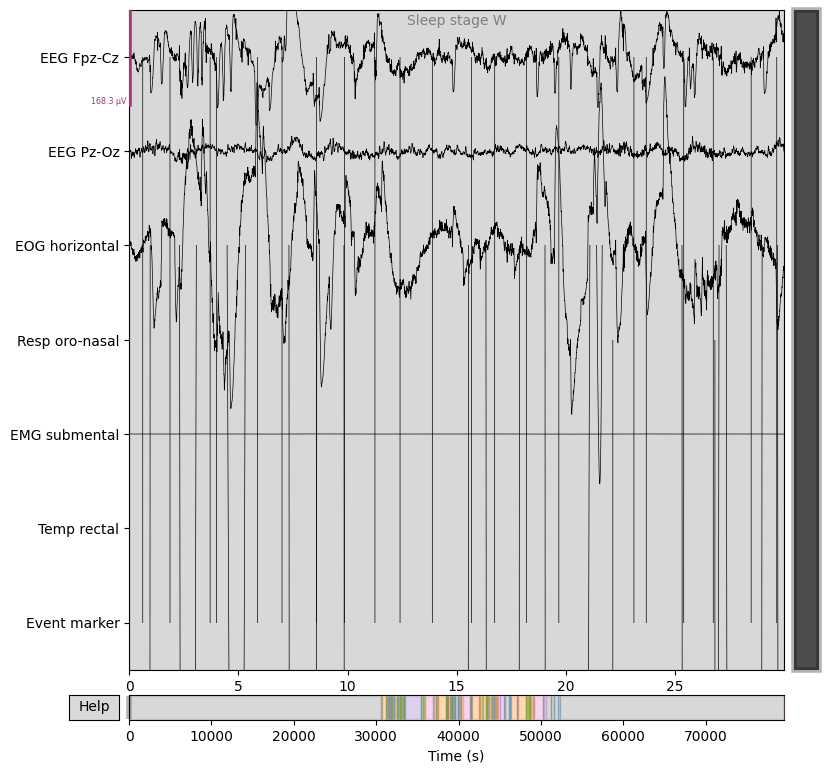

In [7]:
%matplotlib qt

import mne


INPUT_PSG_FILE = "data/sleep-cassette/SC4001E0-PSG.edf"
INPUT_HYPN_FILE = "data/sleep-cassette/SC4001EC-Hypnogram.edf"
psg = mne.io.read_raw_edf(INPUT_PSG_FILE, preload=True)

annot = mne.read_annotations(INPUT_HYPN_FILE)
psg.set_annotations(annot)

print(psg.annotations)

psg.plot(
    scalings="auto",
    duration=30,      # seconds shown at once
    n_channels=len(psg.ch_names),
    block=True
)


In [8]:
import yasa
import numpy as np

sls = yasa.SleepStaging(
    psg,
    eeg_name="EEG Fpz-Cz", # which one?
    eog_name="EOG horizontal",
    emg_name="EMG submental",
)

annot_pred = sls.predict()      # array of stages: W, N1, N2, N3, R
#proba = sls.predict_proba()

c:\Users\E1024679\Documents\RobustSleepStaging\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 0.24.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
